# Phân loại ảnh CT — SARS-CoV-2 CT-scan Dataset (chạy trên PyCharm)

> **Lưu ý môi trường:** cài `timm` có thể kéo theo `torchvision` mới làm hạ `torch` CUDA xuống bản CPU.
> Cell dưới đây tự gắn `torchvision` đúng phiên bản với `torch` đang có. Nếu đã lỡ bị hạ, khôi phục bằng:
> ```bash
> pip install "torch==2.5.1+cu121" "torchvision==0.20.1+cu121" --index-url https://download.pytorch.org/whl/cu121
> ```

Notebook huấn luyện lại mô hình **EfficientNet-B7** (phân loại nhị phân COVID / Non-COVID) trên bộ dữ liệu mới:
**[SARS-CoV-2 CT-scan Dataset](https://www.kaggle.com/datasets/plameneduardo/sarscov2-ctscan-dataset)** — 2482 ảnh CT (1252 COVID / 1230 Non-COVID, Sao Paulo, Brazil).

So với phiên bản Colab gốc, notebook đã thay đổi:
- Bỏ Google Drive / Colab → đường dẫn local, chạy trực tiếp trong PyCharm.
- Bỏ tiền xử lý **KDS sampling** (mỗi mẫu giờ là **1 ảnh**, không phải 8 slice/scan).
- Bỏ đầu **multi-task source** (dataset mới không có nhãn bệnh viện) → chỉ còn BCE nhị phân.
- Giữ nguyên: tiền xử lý SSFL lung extraction, augment, EfficientNet-B7, Adam, đánh giá F1/AUC/ROC.
- Thêm tối ưu huấn luyện: **ReduceLROnPlateau** (giảm LR khi val AUC chững), **early stopping**
  (dừng sớm, `EARLY_STOP=3`), **lưu checkpoint theo AUC** (ổn định hơn F1) và **tune ngưỡng phân loại**
  (sweep 0.05–0.95 trên tập val thay vì mặc định 0.5).
- Thêm cell **Grad-CAM** cuối cùng: trực quan hóa vùng ảnh mà mô hình tập trung (lưu `results/gradcam.png`).

## 1. Cài thư viện
Notebook tự cài khi chạy, hoặc cài trước bằng lệnh:
```bash
pip install timm albumentations scikit-learn opencv-python pandas matplotlib scipy tqdm
```

## 2. Tải dataset (chọn 1 trong 2 cách)

**Cách A — Kaggle CLI:**
```bash
pip install kaggle
# Tạo API token: https://www.kaggle.com/settings -> API -> Create New Token
# Đặt file kaggle.json vào C:\Users\<user>\.kaggle\kaggle.json
kaggle datasets download -d plameneduardo/sarscov2-ctscan-dataset -p data --unzip
```

**Cách B — Tải tay trên web:**
Vào trang dataset ở trên -> **Download** -> giải nén vào thư mục `data/` của dự án này,
sao cho tồn tại 2 thư mục ảnh `CT_COVID/` và `CT_NonCOVID/` (cell sau tự dò tìm, kể cả khi có thư mục bọc ngoài).

## 3. Chạy
Mở file này trong PyCharm (chuột phải -> *Run* hoặc *Debug* từng cell theo thứ tự từ trên xuống).


In [1]:
import subprocess, sys, importlib.util, os, random, zipfile, re
from pathlib import Path

# --- 1. cài thư viện còn thiếu ---
def ensure_torchvision():
    """Cài torchvision hợp với torch đang có (tránh pip tải bản CPU/hạ CUDA)."""
    if importlib.util.find_spec('torchvision') is not None:
        return
    if importlib.util.find_spec('torch') is None:
        return  # timm sẽ cài torch sau
    import torch
    m = re.match(r'(\d+)\.(\d+)\.(\d+)(?:\+(.+))?', torch.__version__)
    tv = f'0.{int(m.group(2)) + 15}.{m.group(3)}'   # torch 2.5.x -> torchvision 0.20.x
    tag = (m.group(4) or '')
    cmd = [sys.executable, '-m', 'pip', 'install', '-q', f'torchvision=={tv}']
    if tag.startswith('cu'):
        cmd += ['--index-url', f'https://download.pytorch.org/whl/{tag}']
    subprocess.check_call(cmd)
    print(f'đã cài torchvision {tv} (torch tag: {tag or "cpu"})')

ensure_torchvision()

REQUIRED = {'timm': 'timm', 'albumentations': 'albumentations', 'sklearn': 'scikit-learn',
            'cv2': 'opencv-python', 'pandas': 'pandas', 'matplotlib': 'matplotlib', 'scipy': 'scipy'}
missing = [pkg for mod, pkg in REQUIRED.items() if importlib.util.find_spec(mod) is None]
if missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + missing)
    print('da cai:', ', '.join(missing))
else:
    print('thu vien day du')

# --- 2. duong dan (tim thu muc chua notebook, de chay tu bat ky working dir nao) ---
BASE = Path.cwd()
if not (BASE / 'MultiSource_COVID_CT.ipynb').exists():
    for cand in [*BASE.parents, *[d for d in BASE.iterdir() if d.is_dir()]]:
        if (cand / 'MultiSource_COVID_CT.ipynb').exists():
            BASE = cand
            break

DATA_DIR   = BASE / 'data'
RAW_DIR    = DATA_DIR / 'raw_sarscov2'          # CT_COVID/ & CT_NonCOVID/ sau khi giai nen
ZIP_PATHS  = [DATA_DIR / 'sarscov2-ctscan-dataset.zip', DATA_DIR / 'archive.zip']
PRE_DIR    = DATA_DIR / 'preprocessed_sarscov2'  # du lieu sau tien xu ly
CKPT_DIR   = BASE / 'checkpoints'
RESULT_DIR = BASE / 'results'
for d in (RAW_DIR, PRE_DIR, CKPT_DIR, RESULT_DIR):
    d.mkdir(parents=True, exist_ok=True)

# --- 3. tham so huan luyen ---
SEED        = 42
VAL_RATIO   = 0.2      # ty le tap val (stratified)
N_EP        = 16       # so epoch (early stop se tu dung som neu AUC khong cai thien)
BATCH       = 8        # VRAM 4GB (RTX 3050 Ti) -> 8; GPU manh hon co the tang len 16-32
LR          = 1e-4
EARLY_STOP  = 3        # dung som neu val AUC khong cai thien sau N epoch lien tiep
MODEL_NAME  = 'tf_efficientnet_b7'   # may CPU/yeu: doi thanh 'tf_efficientnet_b3'
USE_LUNG_EXTRACT = True              # False neu muon huan luyen tren anh goc
NUM_WORKERS = 0 if sys.platform == 'win32' else 2

IMG_EXT = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')

random.seed(SEED)
import numpy as np
np.random.seed(SEED)
import torch
torch.manual_seed(SEED)

dev = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', dev, '|', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')
print('BASE =', BASE)
print(f'epochs={N_EP} batch={BATCH} model={MODEL_NAME} lung_extract={USE_LUNG_EXTRACT}')


da cai: timm, albumentations, scikit-learn, opencv-python, pandas, matplotlib, scipy
device: cpu | CPU
BASE = C:\study\tren_truong\nen_tang_ttnt\project\image_classsification\multisource-covid-ct
epochs=16 batch=8 model=tf_efficientnet_b7 lung_extract=True


In [2]:
# --- giai nen zip (neu tai bang cach khong dung --unzip) va do tim 2 thu muc lop ---
for z in ZIP_PATHS:
    if z.exists():
        print('giai nen', z)
        with zipfile.ZipFile(z) as zf:
            zf.extractall(DATA_DIR)

def _scan_dirs(dirs):
    pos = neg = None
    for d in dirs:
        n = d.name.lower()
        if 'covid' not in n:
            continue
        if not any(f.is_file() and f.suffix.lower() in IMG_EXT for f in d.iterdir()):
            continue
        if 'non' in n or 'normal' in n or 'neg' in n:
            neg = d
        else:
            pos = d
    return pos, neg

def find_class_dirs(root):
    """Do tim 2 thu muc chua anh: lop COVID (1) va Non-COVID (0).
    Uu tien thu muc cap 1 (dang data/COVID, data/non-COVID), sau do moi do sau,
    va loai bo PRE_DIR de khong nham voi du lieu da tien xu ly."""
    root = Path(root)
    if not root.exists():
        return None, None
    top = [d for d in root.iterdir() if d.is_dir()]
    pos, neg = _scan_dirs(top)
    if pos is not None and neg is not None:
        return pos, neg
    deep = [d for d in root.rglob('*')
            if d.is_dir() and d not in top and d != PRE_DIR and PRE_DIR not in d.parents]
    p2, n2 = _scan_dirs(deep)
    return pos or p2, neg or n2

pos_dir, neg_dir = find_class_dirs(RAW_DIR)
if pos_dir is None or neg_dir is None:
    pos_dir, neg_dir = find_class_dirs(DATA_DIR)   # fallback: do toan bo data/
assert pos_dir is not None and neg_dir is not None, \
    'Khong tim thay CT_COVID/ va CT_NonCOVID/ - xem huong dan tai o Markdown dau notebook'

n_pos = len([f for f in pos_dir.iterdir() if f.is_file() and f.suffix.lower() in IMG_EXT])
n_neg = len([f for f in neg_dir.iterdir() if f.is_file() and f.suffix.lower() in IMG_EXT])
print(f'COVID    : {pos_dir}  ({n_pos} anh)')
print(f'Non-COVID: {neg_dir}  ({n_neg} anh)')
print(f'tong = {n_pos + n_neg}')


COVID    : C:\study\tren_truong\nen_tang_ttnt\project\image_classsification\multisource-covid-ct\data\COVID  (1252 anh)
Non-COVID: C:\study\tren_truong\nen_tang_ttnt\project\image_classsification\multisource-covid-ct\data\non-COVID  (1229 anh)
tong = 2481


In [3]:
# --- tien xu ly SSFL lung extraction (giong ban goc, bo KDS sampling vi moi mau chi 1 anh) ---
import cv2
import numpy as np
from scipy.ndimage import minimum_filter, uniform_filter
import warnings
warnings.filterwarnings('ignore')

def is_valid_img(fn):
    if fn.startswith('._') or fn.startswith('.'):
        return False
    return fn.lower().endswith(IMG_EXT)

def spatial_filter(img, ksz=3):
    mf = uniform_filter(img.astype(np.float64), size=ksz)
    mnf = minimum_filter(mf, size=ksz)
    return mnf.astype(np.uint8)

def extract_lung(img, thresh=None):
    filt = spatial_filter(img, ksz=3)
    if thresh is None:
        thresh, _ = cv2.threshold(filt, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        thresh = max(thresh * 0.5, 20)
    msk = np.zeros_like(filt, dtype=np.uint8)
    msk[filt >= thresh] = 1
    cnts, _ = cv2.findContours(msk, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filled = np.zeros_like(msk)
    cv2.drawContours(filled, cnts, -1, 1, thickness=cv2.FILLED)
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    filled = cv2.morphologyEx(filled, cv2.MORPH_CLOSE, k)
    return filled, filt

def crop_lung(img, msk, sz=256):
    coords = np.where(msk > 0)
    if len(coords[0]) == 0:
        return cv2.resize(img, (sz, sz)), 0
    ymin, ymax = coords[0].min(), coords[0].max()
    xmin, xmax = coords[1].min(), coords[1].max()
    p = 5
    ymin = max(0, ymin - p); ymax = min(img.shape[0], ymax + p)
    xmin = max(0, xmin - p); xmax = min(img.shape[1], xmax + p)
    cr = img[ymin:ymax, xmin:xmax]
    return cv2.resize(cr, (sz, sz)), np.sum(msk)

print('preprocessing functions ready')


preprocessing functions ready


In [4]:
# --- chia train/val (stratified) roi tien xu ly ---
from sklearn.model_selection import train_test_split
from tqdm import tqdm

def list_imgs(d):
    return sorted([f for f in d.iterdir() if f.is_file() and f.suffix.lower() in IMG_EXT])

items = [(p, 1) for p in list_imgs(pos_dir)] + [(p, 0) for p in list_imgs(neg_dir)]
tr_items, vl_items = train_test_split(items, test_size=VAL_RATIO, random_state=SEED,
                                      stratify=[y for _, y in items])
print(f'train={len(tr_items)} (covid={sum(1 for _, y in tr_items if y == 1)})  '
      f'val={len(vl_items)} (covid={sum(1 for _, y in vl_items if y == 1)})')

def preprocess(items, split):
    n_ok = 0
    for p, lb in tqdm(items, desc=split):
        cn = 'covid' if lb == 1 else 'non-covid'
        out = PRE_DIR / split / cn
        out.mkdir(parents=True, exist_ok=True)
        im = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
        if im is None:
            continue
        if USE_LUNG_EXTRACT:
            m, _ = extract_lung(im)
            cr, _ = crop_lung(im, m, sz=256)
        else:
            cr = cv2.resize(im, (256, 256))
        cv2.imwrite(str(out / (p.stem + '.png')), cr)
        n_ok += 1
    print(f'{split}: {n_ok} anh')

preprocess(tr_items, 'train')
preprocess(vl_items, 'val')
print('done ->', PRE_DIR)


train=1984 (covid=1001)  val=497 (covid=251)


train: 100%|██████████| 1984/1984 [00:17<00:00, 110.23it/s]


train: 1984 anh


val: 100%|██████████| 497/497 [00:06<00:00, 78.55it/s] 

val: 497 anh
done -> C:\study\tren_truong\nen_tang_ttnt\project\image_classsification\multisource-covid-ct\data\preprocessed_sarscov2


In [5]:
import os, gc, copy
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import (f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve, precision_recall_curve,
                             auc, accuracy_score)
from torch.amp import autocast, GradScaler
import timm
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

IMG_MEAN = [0.485, 0.456, 0.406]; IMG_STD = [0.229, 0.224, 0.225]
tr_tfm = A.Compose([A.Resize(256, 256),
                    A.HorizontalFlip(p=0.5),
                    A.Affine(translate_percent=(-0.2, 0.2), scale=(0.8, 1.2),
                             rotate=(-30, 30), p=0.5),
                    A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=20, val_shift_limit=20, p=0.5),
                    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
                    A.CoarseDropout(num_holes_range=(1, 8),
                                    hole_height_range=(8, 32), hole_width_range=(8, 32), p=0.2),
                    A.Normalize(mean=IMG_MEAN, std=IMG_STD), ToTensorV2()])
vl_tfm = A.Compose([A.Resize(256, 256), A.Normalize(mean=IMG_MEAN, std=IMG_STD), ToTensorV2()])

class CTDataset(Dataset):
    def __init__(self, items, tfm=None):
        self.items = items; self.tfm = tfm
    def __len__(self):
        return len(self.items)
    def __getitem__(self, i):
        info = self.items[i]
        im = cv2.imread(info['path'], cv2.IMREAD_GRAYSCALE)
        im = cv2.cvtColor(im, cv2.COLOR_GRAY2RGB)
        if self.tfm:
            im = self.tfm(image=im)['image']
        return im, torch.tensor(info['label'], dtype=torch.float32)

class EffB7(nn.Module):
    """EfficientNet + 1 dau phan loai nhi phan (bo source head so voi ban goc)."""
    def __init__(self, pt=True, model_name=MODEL_NAME):
        super().__init__()
        self.bb = timm.create_model(model_name, pretrained=pt, num_classes=0)
        fd = self.bb.num_features
        self.cls = nn.Sequential(nn.Dropout(0.3), nn.Linear(fd, 1))
    def forward(self, x):
        return self.cls(self.bb(x)).squeeze(-1)

def do_train(mdl, ldr, opt, crit, sclr, dv):
    mdl.train()
    tot = 0.0; ps = []; ls = []
    for ims, lbls in tqdm(ldr, desc='tr', leave=False):
        ims = ims.to(dv); lbls = lbls.to(dv)
        opt.zero_grad()
        with autocast('cuda', enabled=(dv.type == 'cuda')):
            co = mdl(ims)
            loss = crit(co, lbls)
        sclr.scale(loss).backward()
        sclr.step(opt); sclr.update()
        tot += loss.item() * ims.size(0)
        ps.extend(torch.sigmoid(co).detach().cpu().numpy()); ls.extend(lbls.cpu().numpy())
    return tot / len(ldr.dataset), f1_score(np.array(ls), (np.array(ps) >= 0.5).astype(int))

def do_val(mdl, ldr, crit, dv):
    mdl.eval()
    tot = 0.0; ps = []; ls = []
    with torch.no_grad():
        for ims, lbls in tqdm(ldr, desc='vl', leave=False):
            ims = ims.to(dv); lbls = lbls.to(dv)
            with autocast('cuda', enabled=(dv.type == 'cuda')):
                co = mdl(ims)
                loss = crit(co, lbls)
            tot += loss.item() * ims.size(0)
            ps.extend(torch.sigmoid(co).cpu().numpy()); ls.extend(lbls.cpu().numpy())
    p = np.array(ps); l = np.array(ls)
    f1 = f1_score(l, (p >= 0.5).astype(int))
    try:
        auc_ = roc_auc_score(l, p)
    except Exception:
        auc_ = 0.0
    return tot / len(ldr.dataset), f1, auc_, p, l

print('model + functions ready')


model + functions ready


In [6]:
def build_list(split):
    out = []
    for ln, lb in [('covid', 1), ('non-covid', 0)]:
        d = PRE_DIR / split / ln
        if not d.exists():
            continue
        for p in sorted(d.glob('*.png')):
            out.append({'scan_id': p.stem, 'label': lb, 'label_name': ln, 'path': str(p)})
    return out

tr_data = build_list('train')
vl_data = build_list('val')
assert len(tr_data) > 0 and len(vl_data) > 0, 'Chay cell tien xu ly troc!'
print(f'train={len(tr_data)} (covid={sum(1 for s in tr_data if s["label"] == 1)}, '
      f'non={sum(1 for s in tr_data if s["label"] == 0)})')
print(f'val  ={len(vl_data)} (covid={sum(1 for s in vl_data if s["label"] == 1)}, '
      f'non={sum(1 for s in vl_data if s["label"] == 0)})')


train=1984 (covid=1001, non=983)
val  =497 (covid=251, non=246)


In [7]:
tr_ldr = DataLoader(CTDataset(tr_data, tr_tfm), batch_size=BATCH, shuffle=True,
                    num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
vl_ldr = DataLoader(CTDataset(vl_data, vl_tfm), batch_size=BATCH, shuffle=False,
                    num_workers=NUM_WORKERS, pin_memory=True)

mdl = EffB7(pt=True).to(dev)
opt = torch.optim.Adam(mdl.parameters(), lr=LR, weight_decay=5e-4)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.5,
                                                   patience=1, min_lr=1e-6)
c_crit = nn.BCEWithLogitsLoss()
sclr = GradScaler('cuda', enabled=(dev.type == 'cuda'))

best_f1 = 0; best_auc = 0; best_wts = None
bad = 0                       # dem epoch khong cai thien AUC (early stopping)
hist = {'tl': [], 'tf': [], 'vl': [], 'vf': [], 'va': []}
print(f'epochs={N_EP} batch={BATCH} model={MODEL_NAME} lr={LR} early_stop={EARLY_STOP}')

for ep in range(N_EP):
    print(f'\n{ep + 1}/{N_EP}')
    tl, tf = do_train(mdl, tr_ldr, opt, c_crit, sclr, dev)
    vl, vf, va, _, _ = do_val(mdl, vl_ldr, c_crit, dev)
    hist['tl'].append(tl); hist['tf'].append(tf)
    hist['vl'].append(vl); hist['vf'].append(vf); hist['va'].append(va)
    sched.step(va)             # giam LR khi val AUC khong tot hon
    cur_lr = opt.param_groups[0]['lr']
    print(f'  tr: l={tl:.4f} f1={tf:.4f}')
    print(f'  vl: l={vl:.4f} f1={vf:.4f} auc={va:.4f} lr={cur_lr:.2e}')
    if va > best_auc:          # luu checkpoint theo AUC (on dinh hon F1)
        best_auc = va; best_f1 = vf
        best_wts = copy.deepcopy(mdl.state_dict())
        bad = 0
        print('  ^^ best (auc)')
    else:
        bad += 1
        if bad >= EARLY_STOP:
            print(f'  >> early stop (AUC khong cai thien {EARLY_STOP} epoch lien tiep)')
            break

torch.save(best_wts, CKPT_DIR / 'effnet_best.pth')
print(f'\nbest auc={best_auc:.4f} (f1 cua epoch tot nhat={best_f1:.4f}) -> {CKPT_DIR / "effnet_best.pth"}')


epochs=16 batch=8 model=tf_efficientnet_b7 lr=0.0001 early_stop=3

1/16


  tr: l=0.4351 f1=0.7924
  vl: l=0.2589 f1=0.9157 auc=0.9737 lr=1.00e-04
  ^^ best (auc)

2/16


  tr: l=0.2868 f1=0.8829
  vl: l=0.1542 f1=0.9679 auc=0.9941 lr=1.00e-04
  ^^ best (auc)

3/16


  tr: l=0.2455 f1=0.9075
  vl: l=0.0900 f1=0.9658 auc=0.9957 lr=1.00e-04
  ^^ best (auc)

4/16


  tr: l=0.1839 f1=0.9306
  vl: l=0.1244 f1=0.9695 auc=0.9949 lr=1.00e-04

5/16


...

  tr: l=0.0718 f1=0.9744
  vl: l=0.0365 f1=0.9820 auc=0.9993 lr=5.00e-05
  ^^ best (auc)

9/16


  tr: l=0.0450 f1=0.9825
  vl: l=0.0208 f1=0.9940 auc=0.9999 lr=5.00e-05
  ^^ best (auc)

10/16


  tr: l=0.0757 f1=0.9730
  vl: l=0.0308 f1=0.9921 auc=0.9996 lr=5.00e-05

11/16


  tr: l=0.0890 f1=0.9725
  vl: l=0.0401 f1=0.9842 auc=0.9993 lr=2.50e-05

12/16


  tr: l=0.0431 f1=0.9860
  vl: l=0.0448 f1=0.9862 auc=0.9995 lr=2.50e-05
  >> early stop (AUC khong cai thien 3 epoch lien tiep)

best auc=0.9999 (f1 cua epoch tot nhat=0.9940) -> C:\study\tren_truong\nen_tang_ttnt\project\image_classsification\multisource-covid-ct\checkpoints\effnet_best.pth


In [8]:
# --- danh gia + chon nguong phan loai toi uu tren tap val ---
mdl.load_state_dict(best_wts)
mdl.eval()
allp = []; alll = []
with torch.no_grad():
    for ims, lbls in vl_ldr:
        ims = ims.to(dev)
        with autocast('cuda', enabled=(dev.type == 'cuda')):
            co = mdl(ims)
        allp.extend(torch.sigmoid(co).cpu().numpy()); alll.extend(lbls.numpy())
preds = np.array(allp); labels = np.array(alll)

# sweep nguong 0.05 -> 0.95, chon nguong cho F1 cao nhat
ths = np.arange(0.05, 0.96, 0.01)
f1s = [f1_score(labels, (preds >= t).astype(int)) for t in ths]
THR = float(ths[int(np.argmax(f1s))])
pcls = (preds >= THR).astype(int)
print(f'nguong toi uu = {THR:.2f}  (f1={max(f1s):.4f})')
print(f'  so voi mac dinh 0.50: f1={f1_score(labels, (preds >= 0.5).astype(int)):.4f}')
print(f'acc={accuracy_score(labels, pcls):.4f}  f1={f1_score(labels, pcls):.4f}  '
      f'auc={roc_auc_score(labels, preds):.4f}')
print(classification_report(labels, pcls, target_names=['Non-COVID', 'COVID'], digits=4))


nguong toi uu = 0.26  (f1=0.9960)
  so voi mac dinh 0.50: f1=0.9940
acc=0.9960  f1=0.9960  auc=0.9999
              precision    recall  f1-score   support

   Non-COVID     1.0000    0.9919    0.9959       246
       COVID     0.9921    1.0000    0.9960       251

    accuracy                         0.9960       497
   macro avg     0.9960    0.9959    0.9960       497
weighted avg     0.9960    0.9960    0.9960       497



VALIDATION RESULTS
Accuracy:    0.9960
F1 Score:    0.9960
AUC-ROC:     0.9999
Threshold:   0.26
Sensitivity: 1.0000
Specificity: 0.9919

              precision    recall  f1-score   support

   Non-COVID       1.00      0.99      1.00       246
       COVID       0.99      1.00      1.00       251

    accuracy                           1.00       497
   macro avg       1.00      1.00      1.00       497
weighted avg       1.00      1.00      1.00       497



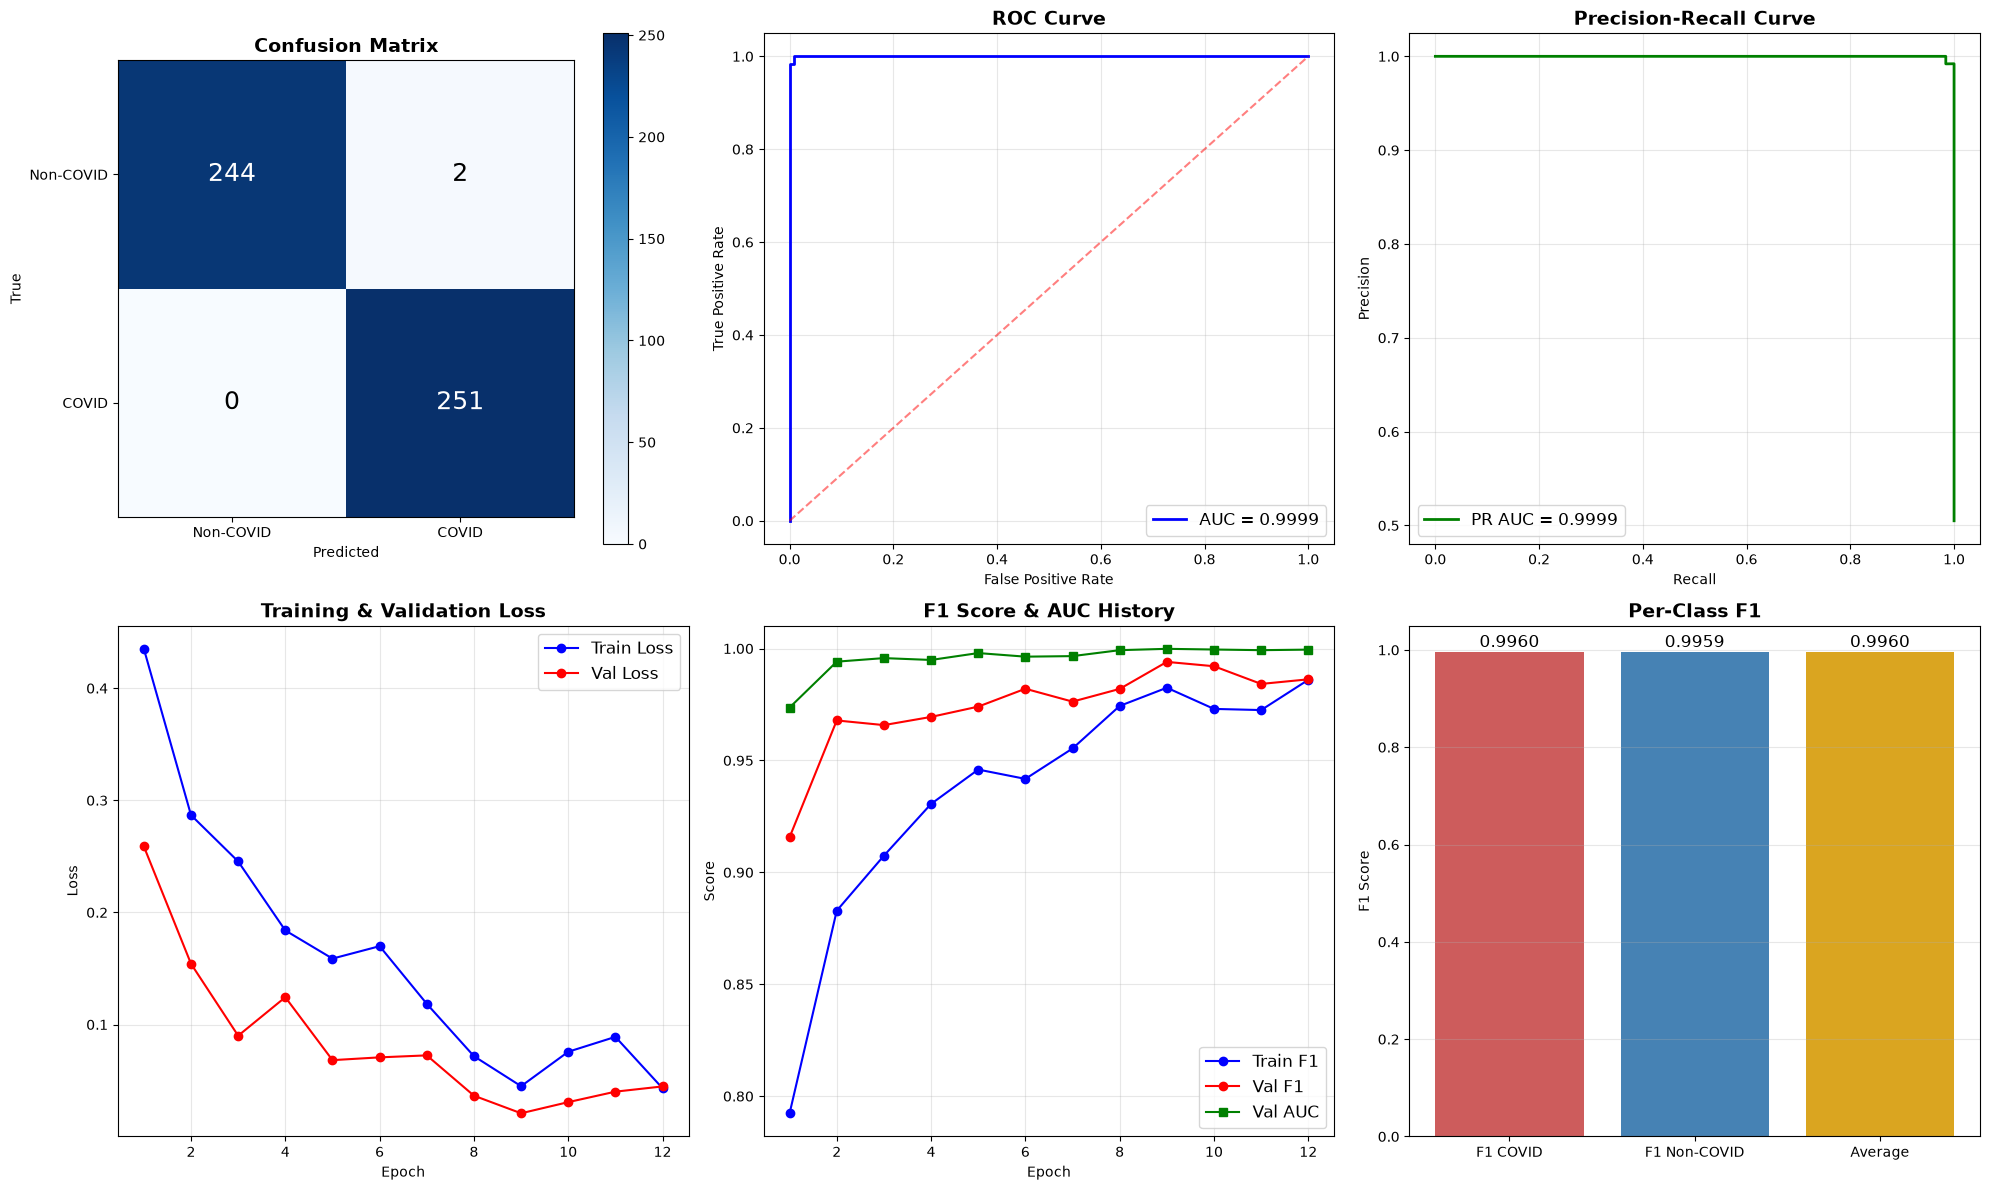

In [9]:
save_dir = RESULT_DIR

mdl.load_state_dict(best_wts)
_, val_f1, val_auc, val_preds, val_labels = do_val(mdl, vl_ldr, c_crit, dev)

vpreds = (val_preds >= THR).astype(int)   # dung nguong da toi uu o o tren
cm = confusion_matrix(val_labels, vpreds)
acc = accuracy_score(val_labels, vpreds)
tn, fp, fn, tp = cm.ravel()
sens = tp / (tp + fn) if (tp + fn) > 0 else 0
spec = tn / (tn + fp) if (tn + fp) > 0 else 0
f1_covid = f1_score(val_labels, vpreds, pos_label=1)
f1_non = f1_score(val_labels, vpreds, pos_label=0)
val_f1 = f1_score(val_labels, vpreds)   # F1 tai nguong toi uu (khop voi confusion matrix)

print('=' * 60)
print('VALIDATION RESULTS')
print('=' * 60)
print(f'Accuracy:    {acc:.4f}')
print(f'F1 Score:    {val_f1:.4f}')
print(f'AUC-ROC:     {val_auc:.4f}')
print(f'Threshold:   {THR:.2f}')
print(f'Sensitivity: {sens:.4f}')
print(f'Specificity: {spec:.4f}')
print(f'\n{classification_report(val_labels, vpreds, target_names=["Non-COVID", "COVID"])}')

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

ax = axes[0, 0]
im = ax.imshow(cm, cmap='Blues')
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Non-COVID', 'COVID']); ax.set_yticklabels(['Non-COVID', 'COVID'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=18,
                color='white' if cm[i, j] > cm.max() / 2 else 'black')
fig.colorbar(im, ax=ax)

fpr, tpr, _ = roc_curve(val_labels, val_preds)
ax = axes[0, 1]
ax.plot(fpr, tpr, 'b-', linewidth=2, label=f'AUC = {val_auc:.4f}')
ax.plot([0, 1], [0, 1], 'r--', alpha=0.5)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve', fontsize=14, fontweight='bold')
ax.legend(fontsize=12); ax.grid(True, alpha=0.3)

precision, recall, _ = precision_recall_curve(val_labels, val_preds)
pr_auc = auc(recall, precision)
ax = axes[0, 2]
ax.plot(recall, precision, 'g-', linewidth=2, label=f'PR AUC = {pr_auc:.4f}')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
ax.legend(fontsize=12); ax.grid(True, alpha=0.3)

ax = axes[1, 0]
eps = range(1, len(hist['tl']) + 1)
ax.plot(eps, hist['tl'], 'b-o', label='Train Loss')
ax.plot(eps, hist['vl'], 'r-o', label='Val Loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
ax.legend(fontsize=12); ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.plot(eps, hist['tf'], 'b-o', label='Train F1')
ax.plot(eps, hist['vf'], 'r-o', label='Val F1')
ax.plot(eps, hist['va'], 'g-s', label='Val AUC')
ax.set_xlabel('Epoch'); ax.set_ylabel('Score')
ax.set_title('F1 Score & AUC History', fontsize=14, fontweight='bold')
ax.legend(fontsize=12); ax.grid(True, alpha=0.3)

ax = axes[1, 2]
bars = [f1_covid, f1_non, (f1_covid + f1_non) / 2]
labels_b = ['F1 COVID', 'F1 Non-COVID', 'Average']
ax.bar(labels_b, bars, color=['indianred', 'steelblue', 'goldenrod'])
for i, v in enumerate(bars):
    ax.text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=12)
ax.set_ylabel('F1 Score'); ax.set_ylim(0, 1.05)
ax.set_title('Per-Class F1', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(save_dir / 'evaluation_plots.png', dpi=150, bbox_inches='tight')
plt.show()


In [10]:
vrecs = []
for i, s in enumerate(vl_data):
    vrecs.append({'file': Path(s['path']).name,
                  'true_label': s['label_name'],
                  'predicted_label': 'covid' if vpreds[i] == 1 else 'non-covid',
                  'prediction_prob': float(val_preds[i]),
                  'correct': int(vpreds[i] == int(val_labels[i]))})
pd.DataFrame(vrecs).to_csv(save_dir / 'val_predictions.csv', index=False)
torch.save(best_wts, save_dir / 'effnet_best.pth')

txt = f"""sarscov2 ct-scan - efficientnet-b7 binary (BCE)
model={MODEL_NAME} lung_extract={USE_LUNG_EXTRACT} img=256x256 seed={SEED}
tr={len(tr_data)} vl={len(vl_data)} epochs={N_EP} batch={BATCH} lr={LR}
acc={acc:.4f} f1={val_f1:.4f} auc={val_auc:.4f} thr={THR:.2f}
sens={sens:.4f} spec={spec:.4f}
TN={cm[0, 0]} FP={cm[0, 1]} FN={cm[1, 0]} TP={cm[1, 1]}
per-class: f1_covid={f1_covid:.4f} f1_noncovid={f1_non:.4f}

epochs:
"""
for i in range(len(hist['tl'])):
    txt += (f"  {i + 1}: tl={hist['tl'][i]:.4f} tf={hist['tf'][i]:.4f} "
            f"vl={hist['vl'][i]:.4f} vf={hist['vf'][i]:.4f} va={hist['va'][i]:.4f}\n")
with open(save_dir / 'results.txt', 'w') as f:
    f.write(txt)
print(txt)
print('saved to', save_dir)


sarscov2 ct-scan - efficientnet-b7 binary (BCE)
model=tf_efficientnet_b7 lung_extract=True img=256x256 seed=42
tr=1984 vl=497 epochs=16 batch=8 lr=0.0001
acc=0.9960 f1=0.9960 auc=0.9999 thr=0.26
sens=1.0000 spec=0.9919
TN=244 FP=2 FN=0 TP=251
per-class: f1_covid=0.9960 f1_noncovid=0.9959

epochs:
  1: tl=0.4351 tf=0.7924 vl=0.2589 vf=0.9157 va=0.9737
  2: tl=0.2868 tf=0.8829 vl=0.1542 vf=0.9679 va=0.9941
  3: tl=0.2455 tf=0.9075 vl=0.0900 vf=0.9658 va=0.9957
  4: tl=0.1839 tf=0.9306 vl=0.1244 vf=0.9695 va=0.9949
  5: tl=0.1588 tf=0.9459 vl=0.0682 vf=0.9741 va=0.9980
  6: tl=0.1699 tf=0.9418 vl=0.0707 vf=0.9820 va=0.9964
  7: tl=0.1185 tf=0.9553 vl=0.0725 vf=0.9763 va=0.9966
  8: tl=0.0718 tf=0.9744 vl=0.0365 vf=0.9820 va=0.9993
  9: tl=0.0450 tf=0.9825 vl=0.0208 vf=0.9940 va=0.9999
  10: tl=0.0757 tf=0.9730 vl=0.0308 vf=0.9921 va=0.9996
  11: tl=0.0890 tf=0.9725 vl=0.0401 vf=0.9842 va=0.9993
  12: tl=0.0431 tf=0.9860 vl=0.0448 vf=0.9862 va=0.9995

saved to C:\study\tren_truong\nen_tang

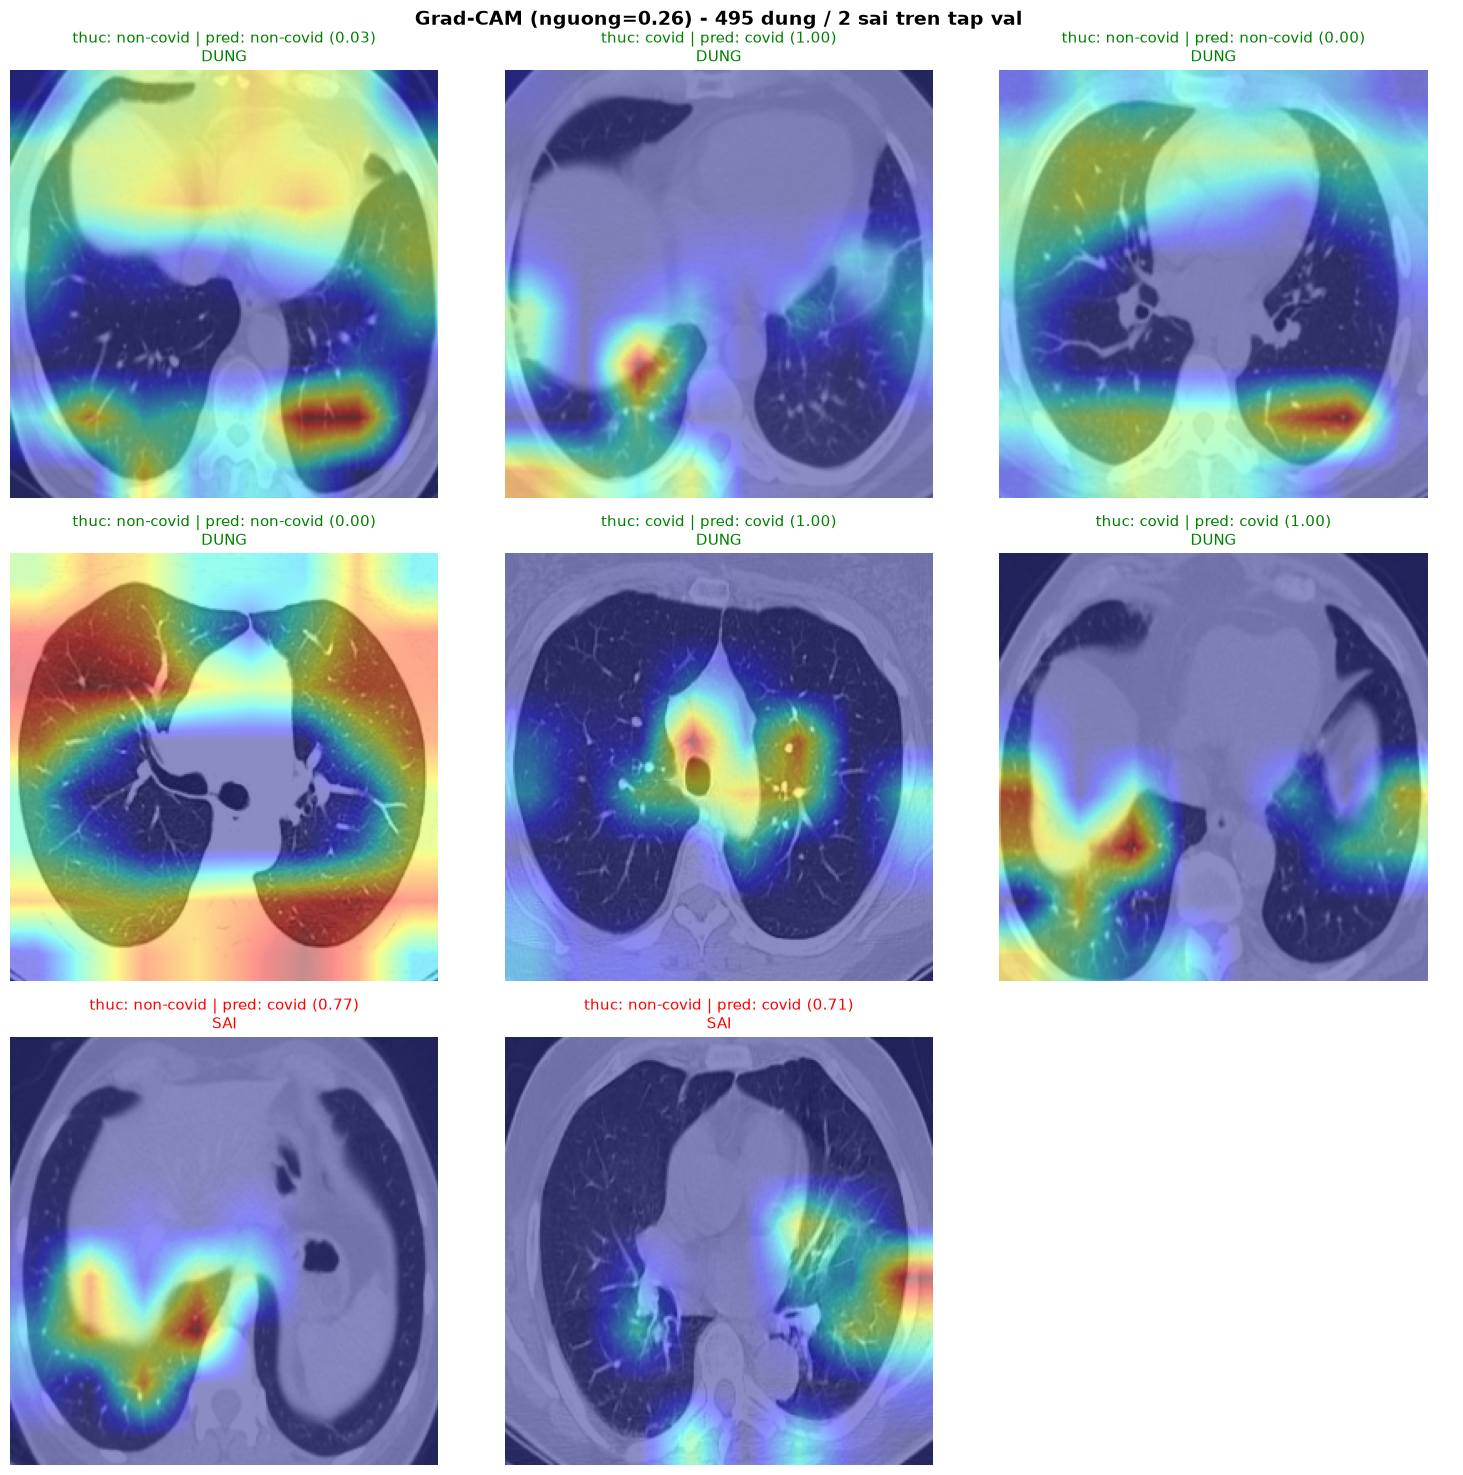

luu -> C:\study\tren_truong\nen_tang_ttnt\project\image_classsification\multisource-covid-ct\results\gradcam.png  (do chinh xac tap val: 495/497)


In [11]:
# --- Grad-CAM: bieu dien vung mau ma mo hinh "nhin" vua duoc phan loai ---
import torch.nn.functional as F

TARGET_LAYER = mdl.bb.conv_head    # conv cuoi cung cua EfficientNet (timm 1.0.x khong co act1)

def get_gradcam(mdl, img_tensor, layer):
    """Tra ve heatmap Grad-CAM (256x256, gia tri 0..1) cho 1 anh input da normalize."""
    acts = {}
    def _hook(m, i, o):
        o.retain_grad()
        acts['a'] = o
    h = layer.register_forward_hook(_hook)
    x = img_tensor.unsqueeze(0).to(dev).detach().requires_grad_(True)
    mdl.zero_grad()
    with torch.amp.autocast('cuda', enabled=(dev.type == 'cuda')):
        logit = mdl(x)
    logit.backward()
    h.remove()
    A = acts['a'].detach().float().cpu()
    G = acts['a'].grad.detach().float().cpu()
    w = G.mean(dim=(2, 3), keepdim=True)                  # weight = trung binh gradient theo channel
    cam = F.relu((w * A).sum(dim=1, keepdim=True))
    cam = F.interpolate(cam, size=img_tensor.shape[-2:], mode='bilinear', align_corners=False)
    cam = cam[0, 0]
    if cam.max() > cam.min():
        cam = (cam - cam.min()) / (cam.max() - cam.min())
    return cam.numpy()

mdl.load_state_dict(best_wts)
mdl.eval()
vp = (val_preds >= THR).astype(int)
ok_idx = [i for i in range(len(vl_data)) if vp[i] == int(val_labels[i])]
bad_idx = [i for i in range(len(vl_data)) if vp[i] != int(val_labels[i])]
random.seed(0)
sel = random.sample(ok_idx, min(6, len(ok_idx))) + random.sample(bad_idx, min(3, len(bad_idx)))

n = len(sel); ncol = 3; nrow = (n + ncol - 1) // ncol
fig, axes = plt.subplots(nrow, ncol, figsize=(5 * ncol, 5 * nrow))
axes = np.atleast_1d(axes).ravel()
mean = np.array(IMG_MEAN); std = np.array(IMG_STD)
for k, ax in enumerate(axes):
    if k >= n:
        ax.axis('off'); continue
    i = sel[k]
    im = cv2.imread(vl_data[i]['path'], cv2.IMREAD_GRAYSCALE)
    im = cv2.cvtColor(im, cv2.COLOR_GRAY2RGB)
    ten = vl_tfm(image=im)['image']                      # tensor (3,256,256) da normalize
    cam = get_gradcam(mdl, ten, TARGET_LAYER)
    disp = ten.permute(1, 2, 0).numpy() * std + mean     # chuyen ve thang hien thi
    ax.imshow(np.clip(disp, 0, 1))
    ax.imshow(cam, cmap='jet', alpha=0.45)
    truth = vl_data[i]['label_name']; prob = float(val_preds[i])
    pred = 'covid' if vp[i] == 1 else 'non-covid'
    ok = vp[i] == int(val_labels[i])
    ax.set_title(f'thuc: {truth} | pred: {pred} ({prob:.2f})\n{"DUNG" if ok else "SAI"}',
                 fontsize=11, color='green' if ok else 'red')
    ax.axis('off')
plt.suptitle(f'Grad-CAM (nguong={THR:.2f}) - {len(ok_idx)} dung / {len(bad_idx)} sai tren tap val',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(save_dir / 'gradcam.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'luu -> {save_dir / "gradcam.png"}  (do chinh xac tap val: {len(ok_idx)}/{len(vl_data)})')
